In [21]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import os
import multiprocessing as mp
import pyrfu.pyrf
from pyrfu.plot import plot_line, plot_spectr
import matplotlib.pyplot as plt
from sw_density_from_fpe import sw_density_from_fpe
from ne2fpe import ne2fpe


# 1. Read list of compiled solar wind (run_sw_density_parallel.py)

In [18]:
n_rans = 1
random_indices = np.random.randint(0, 4000, n_rans)

[14-Jan-26 15:12:06] INFO: Loading mms1_edp_scpot_fast_l2...
[14-Jan-26 15:12:06] INFO: Loading mms1_dsp_epsd_omni...
[14-Jan-26 15:12:07] INFO: Using averages in resample
[14-Jan-26 15:12:07] INFO: Loading mms1_des_numberdensity_fast...


[1/1]	1		['2021-03-05T15:23:06.000000000', '2021-03-05T19:48:45.000000000']	Y


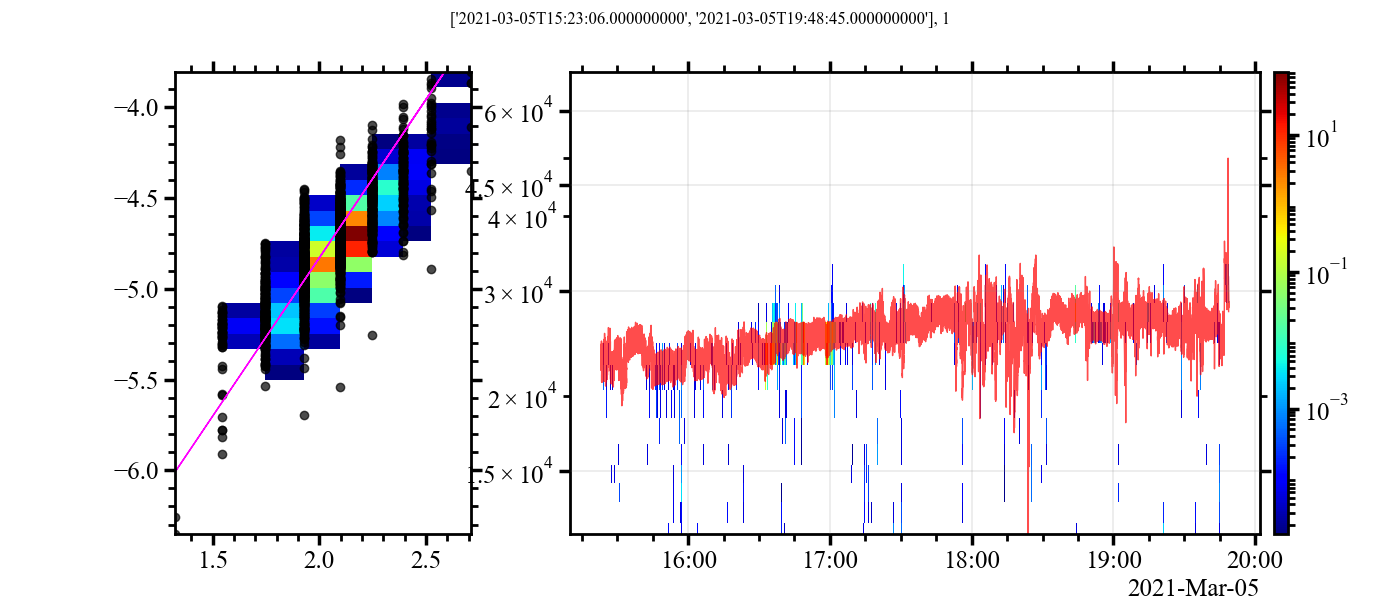

In [23]:
start_times, end_times, sc_ids, sw_mode = np.genfromtxt('sw_tints/compiled_sw_tints4.csv', dtype=str, delimiter=',', skip_header=1).T
sw_tints = np.array([start_times, end_times]).T.tolist()
ntints = len(sw_tints)
out_path = '2026/output_data/'
os.makedirs(out_path, exist_ok=True)
parallel = False
if parallel:
    num_workers = 1
    with mp.Pool(num_workers) as pool:
        results = pool.starmap(sw_density_from_fpe, [(tint, sc_ids[i], sw_mode[i],0, [i, ntints], out_path) for i, tint in enumerate(sw_tints[:])], chunksize=32)
else:
    out_tot = []
    
    
    for i, tint in enumerate(np.array(sw_tints)[random_indices]):
        tint_i = tint.tolist()
        ic_i = sc_ids[i]
        sw_mode_i = sw_mode[i]
        plot_result = 1
        progress_track_i = [i, n_rans]
        out_i = sw_density_from_fpe(tint_i, ic_i, sw_mode_i, plot_result, progress_track_i, out_path)
        out_tot.append(out_i)

<Axes: >

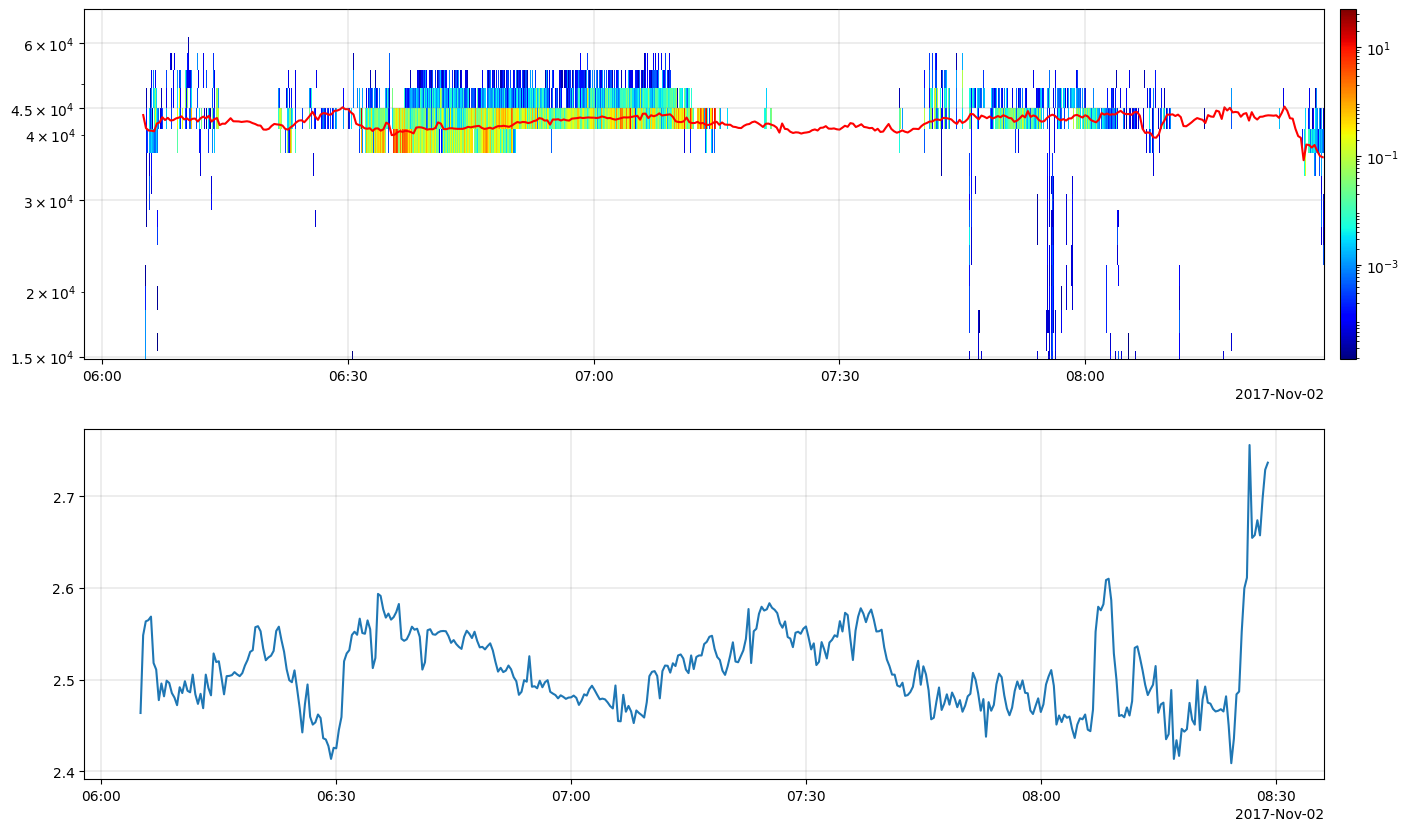

In [ ]:
# ne, vsc_fitted, N0, beta, epsd_data_filt, vsc = out_tot[1]
# fig, [ax_epsd, ax_n]= plt.subplots(nrows=2, figsize=(16, 10))
# # plot_line(ax, ne)
# # ax_fit.scatter(np.log10(ne), -vsc_fitted)
# plot_spectr(ax_epsd, epsd_data_filt, yscale='log', cscale='log', cmap='jet')
# nfit = N0 * np.exp(-vsc / beta)
# plot_line(ax_epsd, ne2fpe(nfit), c='r')


# plot_line(ax_n, vsc)